In [25]:
import pandas as pd
import numpy as np
import os
import glob 
import matplotlib.pyplot as plt

# Parser

In [26]:
def read_mpa_file(filepath):
    realtime = None
    totalsum = None
    roisum = None

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("REALTIME") and realtime is None:
                realtime = float(line.split()[1].strip())
            elif line.startswith("TOTALSUM") and totalsum is None:
                totalsum = float(line.split()[1].strip())

    return realtime, totalsum

def get_hv(filename):
    name_only = filename.replace("HV", "").replace(".mpa", "")
    name_only = name_only.split("_")[0]
    return int(name_only)

def get_run(filename):
    name_only = filename.replace("HV", "").replace(".mpa", "")
    if "_" in name_only:
        return int(name_only.split("_")[1])
    return 1

data_folder = "HVControl"
rows = []

for filepath in glob.glob(os.path.join(data_folder, "HV*.mpa")):
    filename = os.path.basename(filepath)

    hv = get_hv(filename)
    run = get_run(filename)
    realtime, totalsum = read_mpa_file(filepath)
    rate = totalsum / realtime

    rows.append({
        "hv_volts": hv,
        "run": run,
        "file": filename,
        "realtime_s": realtime,
        "totalsum": totalsum,
        "rate_hz": rate
    })

# Data Collection

In [27]:
df = pd.DataFrame(rows)
df = df.sort_values(["hv_volts", "run"]).reset_index(drop=True)
df

,hv_volts,run,file,realtime_s,totalsum,rate_hz
0,1000,1,HV1000.mpa,150.345,3.0,0.019954
1,1050,1,HV1050.mpa,150.576,7.0,0.046488
2,1100,1,HV1100.mpa,150.349,11.0,0.073163
3,1150,1,HV1150.mpa,150.801,9.0,0.059681
4,1200,1,HV1200.mpa,150.353,6.0,0.039906
...,...,...,...,...,...,...
133,2400,1,HV2400.mpa,151.176,20124.0,133.116368
134,2425,1,HV2425.mpa,150.940,22204.0,147.104810
135,2450,1,HV2450.mpa,150.348,26621.0,177.062548
136,2475,1,HV2475.mpa,151.117,30517.0,201.942865


# Plotting

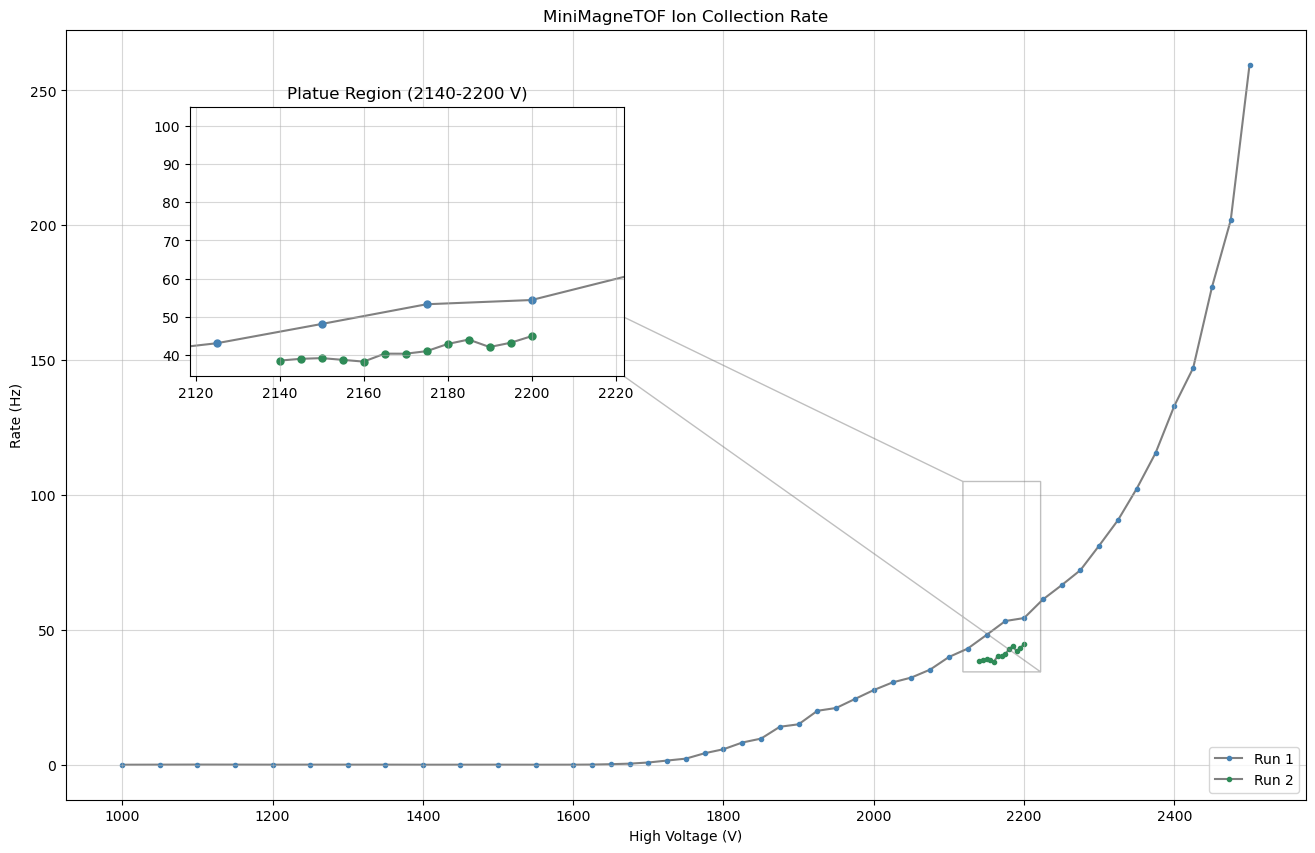

In [28]:
fig, ax = plt.subplots(figsize=(16, 10))

run1 = df[df["run"] == 1]
run2 = df[df["run"] == 2]

# Run 1 Points:
ax.plot(run1["hv_volts"], run1["rate_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=3, markerfacecolor='steelblue', markeredgecolor='steelblue', label="Run 1")
# Run 2 Points:
ax.plot(run2["hv_volts"], run2["rate_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=3, markerfacecolor='seagreen', markeredgecolor='seagreen', label="Run 2")
ax.set_title("MiniMagneTOF Ion Collection Rate")
ax.set_xlabel("High Voltage (V)")
ax.set_ylabel("Rate (Hz)")
ax.grid(alpha=0.5)
ax.legend(loc="lower right")

ax_inset = ax.inset_axes([0.1, 0.55, 0.35, 0.35])
ax_inset.plot(run1["hv_volts"], run1["rate_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=5, markerfacecolor='steelblue', markeredgecolor='steelblue')
ax_inset.plot(run2["hv_volts"], run2["rate_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=5, markerfacecolor='seagreen', markeredgecolor='seagreen')
ax_inset.set_xlim(2140 * 0.99, 2200 * 1.01)

mask = (df["hv_volts"] >= 2140) & (df["hv_volts"] <= 2200)
y_in_range = df.loc[mask, "rate_hz"]
ax_inset.set_ylim(y_in_range.min() * 0.90, y_in_range.max() * 1.10)
ax_inset.grid(alpha=0.5)
ax_inset.set_title("Platue Region (2140-2200 V)")

ax.indicate_inset_zoom(ax_inset, edgecolor="gray")

plt.show()

In [32]:
# Testing again with the Pump Gauge off and 10V floating potential on. Filament Current set to 0.85A
# Ramping MiniMagneTOF voltage from [1750,2250]
# TDC Threshold set to -0.007V = -7mV

rows = []

for filepath in glob.glob(os.path.join(data_folder, "HV*.mpa")):
    filename = os.path.basename(filepath)
    run = get_run(filename)

    if run not in (3,4):
        continue # skips the old run 1/2 files (floating potential wasn't on)

    hv = get_hv(filename)
    realtime, totalsum = read_mpa_file(filepath)
    rate = totalsum / realtime


    rows.append({
        "hv_volts": hv,
        "run": run,
        "file": filename,
        "realtime_s": realtime,
        "totalsum": totalsum,
        "rate_hz": rate
    })

df_valid = pd.DataFrame(rows)
df_valid = df_valid.sort_values(["hv_volts", "run"]).reset_index(drop=True)
df_valid

,hv_volts,run,file,realtime_s,totalsum,rate_hz
0,1500,3,HV1500_3.mpa,150.131,3.0,0.019983
1,1520,3,HV1520_3.mpa,150.146,2.0,0.013320
2,1540,3,HV1540_3.mpa,150.130,5.0,0.033304
3,1560,3,HV1560_3.mpa,150.134,7.0,0.046625
4,1580,3,HV1580_3.mpa,150.134,2.0,0.013321
...,...,...,...,...,...,...
71,2210,4,HV2210_4.mpa,120.020,10640.0,88.651891
72,2220,4,HV2220_4.mpa,120.409,10750.0,89.279041
73,2230,4,HV2230_4.mpa,120.130,10418.0,86.722717
74,2240,4,HV2240_4.mpa,120.030,9606.0,80.029993


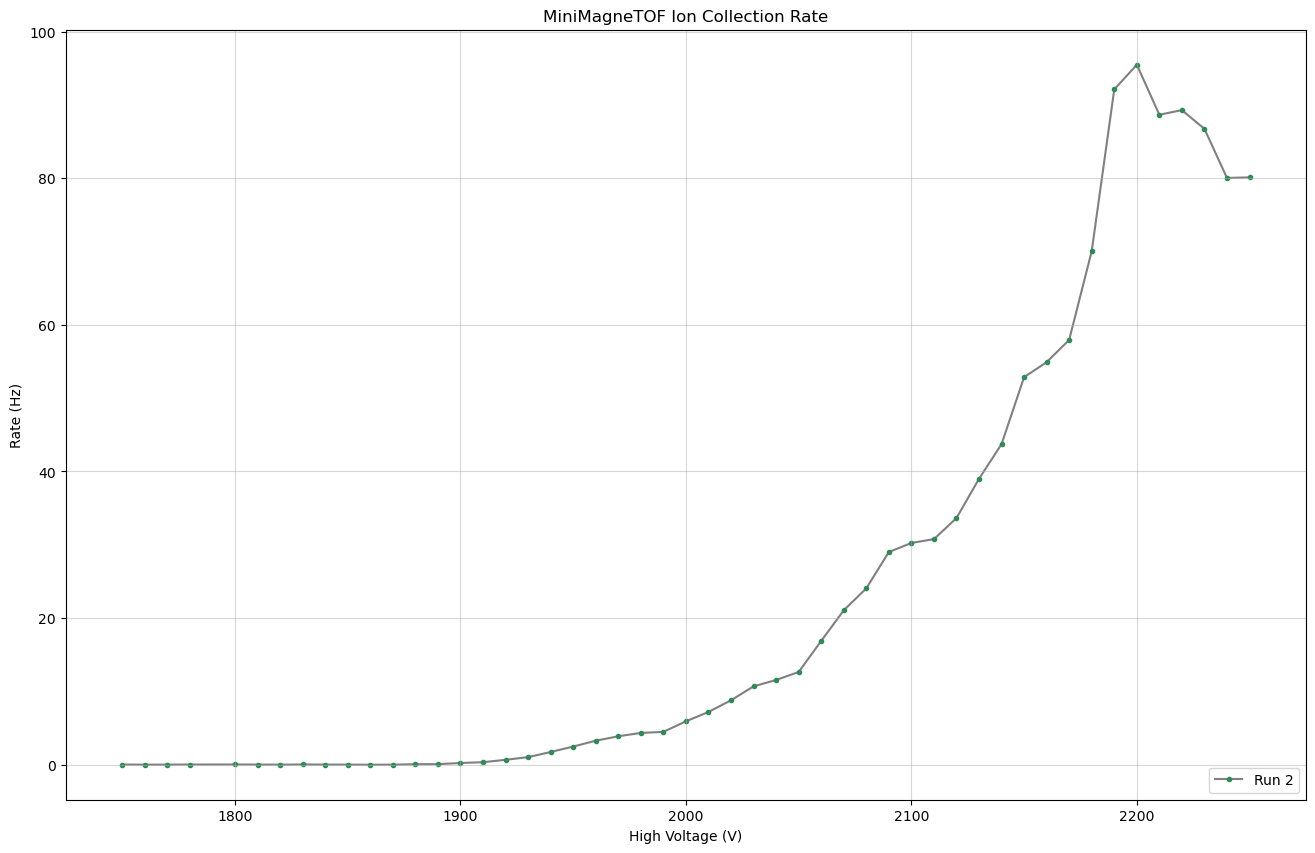

In [30]:
fig, ax = plt.subplots(figsize=(16, 10))

run4 = df[df["run"] == 4]

# Run 4 Points:
ax.plot(run4["hv_volts"], run4["rate_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=3, markerfacecolor='seagreen', markeredgecolor='seagreen', label="Run 2")
ax.set_title("MiniMagneTOF Ion Collection Rate")
ax.set_xlabel("High Voltage (V)")
ax.set_ylabel("Rate (Hz)")
ax.grid(alpha=0.5)
ax.legend(loc="lower right")

# ax_inset = ax.inset_axes([0.1, 0.55, 0.35, 0.35])
# ax_inset.plot(run4["hv_volts"], run4["rate_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=5, markerfacecolor='seagreen', markeredgecolor='seagreen')
# ax_inset.set_xlim(2000 * 0.99, 2150 * 1.01)

# mask = (run4["hv_volts"] >= 2000) & (run4["hv_volts"] <= 2150)
# y_in_range = run4.loc[mask, "rate_hz"]
# ax_inset.set_ylim(y_in_range.min() * 0.90, y_in_range.max() * 1.10)
# ax_inset.grid(alpha=0.5)
# ax_inset.set_title("Platue Region (2140-2200 V)")

# ax.indicate_inset_zoom(ax_inset, edgecolor="gray")